# Chapter 41 — GT-Seeded Cell Division Training Examples

Chapter 40 showed that starting from heuristic triplets can leave every candidate unlabeled. Chapter 41 reverses the direction:

```text
Known GT division → predicted parent/daughter track candidates → positive triplets + hard negatives → supervised training table
```

Inputs:
- `/kaggle/input/datasets/emailchrismathews/data39`
- `/kaggle/input/datasets/emailchrismathews/data40`
- Biohub competition training data

Main output: `chapter41_gt_seeded_training_examples.csv`.

In [1]:
!pip install -q zarr lightgbm joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 77.0 MB/s eta 0:00:00


In [2]:
from __future__ import annotations
from collections import defaultdict
from dataclasses import dataclass
from itertools import product
from pathlib import Path
import json, shutil, warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.pipeline import Pipeline
from IPython.display import display
warnings.filterwarnings("ignore")

## Step 1 — Configuration

In [3]:
@dataclass(frozen=True)
class Config:
    sample_id: str = "44b6_12dfb391"
    z_scale: float = 1.625
    y_scale: float = 0.40625
    x_scale: float = 0.40625
    parent_search_radius_physical: float = 12.0
    daughter_search_radius_physical: float = 12.0
    endpoint_window: int = 5
    top_parent_tracks_per_gt: int = 8
    top_daughter_tracks_per_gt: int = 12
    positives_per_division: int = 5
    hard_negatives_per_division: int = 100
    minimum_positive_examples_to_train: int = 2
    minimum_negative_examples_to_train: int = 10
    random_state: int = 42

CONFIG=Config()
DATA39_DIR=Path('/kaggle/input/datasets/emailchrismathews/data39')
DATA40_DIR=Path('/kaggle/input/datasets/emailchrismathews/data40')
OUTPUT_DIR=Path('/kaggle/working'); OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
print(CONFIG)
print('data39 exists:',DATA39_DIR.exists())
print('data40 exists:',DATA40_DIR.exists())

Config(sample_id='44b6_12dfb391', z_scale=1.625, y_scale=0.40625, x_scale=0.40625, parent_search_radius_physical=12.0, daughter_search_radius_physical=12.0, endpoint_window=5, top_parent_tracks_per_gt=8, top_daughter_tracks_per_gt=12, positives_per_division=5, hard_negatives_per_division=100, minimum_positive_examples_to_train=2, minimum_negative_examples_to_train=10, random_state=42)
data39 exists: True
data40 exists: False


## Step 2 — Locate and load refined tracks

In [4]:
def first_existing(*paths):
    for p in paths:
        p=Path(p)
        if p.exists(): return p
    raise FileNotFoundError('None found:\n'+'\n'.join(map(str,paths)))

TRACK_NODES_PATH=first_existing(DATA39_DIR/'chapter37_refined_track_nodes.csv',DATA40_DIR/'chapter37_refined_track_nodes.csv')
TRACK_SUMMARY_PATH=first_existing(DATA39_DIR/'chapter37_refined_track_summary.csv',DATA40_DIR/'chapter37_refined_track_summary.csv')
track_nodes_df=pd.read_csv(TRACK_NODES_PATH)
track_summary_df=pd.read_csv(TRACK_SUMMARY_PATH)
print('Track nodes:',len(track_nodes_df),'Unique tracks:',track_nodes_df.track_id.nunique())
display(track_nodes_df.head())

Track nodes: 4642 Unique tracks: 591


,track_id,detection_id,t,z,y,x,z_physical,y_physical,x_physical,rank_position,pred_dist,original_track_id
0,0,chapter34_t0_0,0,41.0,130.0,131.0,66.625,52.81250,53.21875,1,7.354238,0
1,0,chapter34_t1_66,1,40.0,127.0,127.0,65.000,51.59375,51.59375,67,17.145113,0
2,0,chapter34_t5_121,5,36.0,80.0,82.0,58.500,32.50000,33.31250,122,17.788210,0
3,0,chapter34_t6_108,6,35.0,78.0,72.0,56.875,31.68750,29.25000,109,17.851830,0
4,1,chapter34_t0_1,0,24.0,123.0,85.0,39.000,49.96875,34.53125,2,7.437489,1


## Step 3 — Load GEFF and true divisions

In [5]:
def find_geff_path(sample_id):
    expected=Path('/kaggle/input/competitions/biohub-cell-tracking-during-development/train')/f'{sample_id}.geff'
    if expected.exists(): return expected
    matches=list(Path('/kaggle/input').rglob(f'{sample_id}.geff'))
    if matches: return sorted(matches,key=lambda p:len(str(p)))[0]
    raise FileNotFoundError(f'Could not find {sample_id}.geff')

def load_geff(sample_id):
    path=find_geff_path(sample_id); g=zarr.open(path,mode='r')
    nodes=pd.DataFrame({'gt_node_id':np.asarray(g['nodes/ids'][:]),'t':np.asarray(g['nodes/props/t/values'][:]).astype(int),'z':np.asarray(g['nodes/props/z/values'][:]).astype(float),'y':np.asarray(g['nodes/props/y/values'][:]).astype(float),'x':np.asarray(g['nodes/props/x/values'][:]).astype(float)})
    e=np.asarray(g['edges/ids'][:]); edges=pd.DataFrame({'gt_source':e[:,0],'gt_target':e[:,1]})
    return path,nodes,edges

geff_path,gt_nodes_df,gt_edges_df=load_geff(CONFIG.sample_id)
node_lookup=gt_nodes_df.set_index('gt_node_id'); children=defaultdict(list)
for r in gt_edges_df.itertuples(index=False): children[r.gt_source].append(r.gt_target)
rows=[]
for parent,ds in children.items():
    ds=sorted(set(ds))
    if len(ds)!=2 or parent not in node_lookup.index or any(d not in node_lookup.index for d in ds): continue
    p=node_lookup.loc[parent]; a=node_lookup.loc[ds[0]]; b=node_lookup.loc[ds[1]]
    rows.append({'gt_parent':parent,'gt_daughter_a':ds[0],'gt_daughter_b':ds[1],'parent_t':int(p.t),'daughter_t_a':int(a.t),'daughter_t_b':int(b.t),'parent_z':float(p.z),'parent_y':float(p.y),'parent_x':float(p.x),'daughter_a_z':float(a.z),'daughter_a_y':float(a.y),'daughter_a_x':float(a.x),'daughter_b_z':float(b.z),'daughter_b_y':float(b.y),'daughter_b_x':float(b.x)})
gt_divisions_df=pd.DataFrame(rows)
print('GEFF:',geff_path); print('GT nodes:',len(gt_nodes_df),'GT edges:',len(gt_edges_df),'GT divisions:',len(gt_divisions_df)); display(gt_divisions_df)

GEFF: /kaggle/input/competitions/biohub-cell-tracking-during-development/train/44b6_12dfb391.geff
GT nodes: 788 GT edges: 773 GT divisions: 1


,gt_parent,gt_daughter_a,gt_daughter_b,parent_t,daughter_t_a,daughter_t_b,parent_z,parent_y,parent_x,daughter_a_z,daughter_a_y,daughter_a_x,daughter_b_z,daughter_b_y,daughter_b_x
0,172000000050,173000000050,173000000051,66,67,67,46.0,63.0,160.0,46.0,51.0,160.0,46.0,74.0,164.0


## Step 4 — Add physical coordinates

In [6]:
for df in (track_nodes_df,gt_nodes_df):
    df['z_physical']=df['z'].astype(float)*CONFIG.z_scale
    df['y_physical']=df['y'].astype(float)*CONFIG.y_scale
    df['x_physical']=df['x'].astype(float)*CONFIG.x_scale

gt_phys=gt_nodes_df.set_index('gt_node_id')
track_groups={int(t):g.sort_values('t').copy() for t,g in track_nodes_df.groupby('track_id')}
print('Track groups:',len(track_groups))

Track groups: 591


## Step 5 — Score predicted tracks against a GT role

In [7]:
def score_track(track_group,gt_node_id,role):
    endpoint=track_group.tail(CONFIG.endpoint_window) if role=='parent' else track_group.head(CONFIG.endpoint_window)
    gt=gt_phys.loc[gt_node_id]
    gt_xyz=np.array([gt.z_physical,gt.y_physical,gt.x_physical],dtype=float)
    xyz=endpoint[['z_physical','y_physical','x_physical']].to_numpy(float)
    d=np.linalg.norm(xyz-gt_xyz[None,:],axis=1); i=int(np.argmin(d)); hit=endpoint.iloc[i]
    radius=CONFIG.parent_search_radius_physical if role=='parent' else CONFIG.daughter_search_radius_physical
    temporal_gap=abs(int(hit.t)-int(gt.t)); nearby=int((d<=radius).sum())
    return {'track_id':int(track_group.track_id.iloc[0]),'gt_node_id':gt_node_id,'role':role,'gt_t':int(gt.t),'closest_detection_id':hit.detection_id,'closest_t':int(hit.t),'min_distance_physical':float(d[i]),'temporal_gap':temporal_gap,'nearby_endpoint_detections':nearby,'track_length':len(track_group),'mean_rank':float(track_group.rank_position.mean()) if 'rank_position' in track_group else np.nan,'mean_pred_dist':float(track_group.pred_dist.mean()) if 'pred_dist' in track_group else np.nan,'role_score':float(d[i]+2*temporal_gap-0.25*nearby)}

def candidates_for_gt(gt_node_id,role,top_n):
    radius=CONFIG.parent_search_radius_physical if role=='parent' else CONFIG.daughter_search_radius_physical
    rows=[]
    for g in track_groups.values():
        s=score_track(g,gt_node_id,role)
        if s['min_distance_physical']<=radius and s['temporal_gap']<=3: rows.append(s)
    if not rows: return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(['role_score','min_distance_physical','temporal_gap']).head(top_n).reset_index(drop=True)
print('Scoring functions loaded.')

Scoring functions loaded.


## Step 6 — Find GT-seeded parent and daughter track candidates

In [8]:
tables=[]
for idx,d in gt_divisions_df.iterrows():
    specs=[('parent',d.gt_parent,'parent',CONFIG.top_parent_tracks_per_gt),('daughter_a',d.gt_daughter_a,'daughter',CONFIG.top_daughter_tracks_per_gt),('daughter_b',d.gt_daughter_b,'daughter',CONFIG.top_daughter_tracks_per_gt)]
    for role_name,node_id,score_role,n in specs:
        t=candidates_for_gt(node_id,score_role,n)
        if t.empty: continue
        t['division_index']=idx; t['division_role']=role_name; tables.append(t)
gt_track_candidates_df=pd.concat(tables,ignore_index=True) if tables else pd.DataFrame()
print('GT-seeded track candidates:',len(gt_track_candidates_df))
display(gt_track_candidates_df[['division_index','division_role','gt_node_id','track_id','min_distance_physical','temporal_gap','nearby_endpoint_detections','role_score']].head(50))

GT-seeded track candidates: 1


,division_index,division_role,gt_node_id,track_id,min_distance_physical,temporal_gap,nearby_endpoint_detections,role_score
0,0,parent,1.720000e+11,196,11.955075,2,1,15.705075


## Step 7 — Check role coverage

In [9]:
# ============================================================
# STEP 7 — SIMPLE GT DIVISION DIAGNOSTIC
# ============================================================

def get_gt_node_row(gt_node_id):
    matches = gt_nodes_df[
        gt_nodes_df["gt_node_id"] == gt_node_id
    ]

    if matches.empty:
        raise KeyError(
            f"GT node {gt_node_id} was not found."
        )

    return matches.iloc[0]


if gt_divisions_df.empty:
    raise RuntimeError(
        "No GT divisions were found."
    )


division = gt_divisions_df.iloc[0]

gt_parent = division["gt_parent"]
gt_daughter_a = division["gt_daughter_a"]
gt_daughter_b = division["gt_daughter_b"]


parent_gt_row = get_gt_node_row(
    gt_parent
)

daughter_a_gt_row = get_gt_node_row(
    gt_daughter_a
)

daughter_b_gt_row = get_gt_node_row(
    gt_daughter_b
)


print("=" * 70)
print("KNOWN GT DIVISION")
print("=" * 70)

print(
    "GT parent:",
    int(gt_parent)
)

print(
    "GT daughter A:",
    int(gt_daughter_a)
)

print(
    "GT daughter B:",
    int(gt_daughter_b)
)

print()

print(
    "Parent time:",
    int(parent_gt_row["t"])
)

print(
    "Daughter A time:",
    int(daughter_a_gt_row["t"])
)

print(
    "Daughter B time:",
    int(daughter_b_gt_row["t"])
)

print()

gt_coordinate_preview = pd.DataFrame(
    [
        {
            "role": "parent",
            "gt_node_id": gt_parent,
            "t": parent_gt_row["t"],
            "z": parent_gt_row["z"],
            "y": parent_gt_row["y"],
            "x": parent_gt_row["x"],
        },
        {
            "role": "daughter_a",
            "gt_node_id": gt_daughter_a,
            "t": daughter_a_gt_row["t"],
            "z": daughter_a_gt_row["z"],
            "y": daughter_a_gt_row["y"],
            "x": daughter_a_gt_row["x"],
        },
        {
            "role": "daughter_b",
            "gt_node_id": gt_daughter_b,
            "t": daughter_b_gt_row["t"],
            "z": daughter_b_gt_row["z"],
            "y": daughter_b_gt_row["y"],
            "x": daughter_b_gt_row["x"],
        },
    ]
)

display(gt_coordinate_preview)

print()
print("Step 7A complete.")

KNOWN GT DIVISION
GT parent: 172000000050
GT daughter A: 173000000050
GT daughter B: 173000000051

Parent time: 66
Daughter A time: 67
Daughter B time: 67



,role,gt_node_id,t,z,y,x
0,parent,1.720000e+11,66.0,46.0,63.0,160.0
1,daughter_a,1.730000e+11,67.0,46.0,51.0,160.0
2,daughter_b,1.730000e+11,67.0,46.0,74.0,164.0



Step 7A complete.


## Step 8 — Triplet feature builder

In [10]:
def endpoint_row(track_id,which):
    g=track_groups[int(track_id)]
    return g.iloc[0] if which=='start' else g.iloc[-1]

def xyz(row): return np.array([row.z_physical,row.y_physical,row.x_physical],dtype=float)

def triplet_features(idx,p,a,b,label,kind):
    pt,at,bt=int(p['track_id']),int(a['track_id']),int(b['track_id'])
    pe,as_,bs_=endpoint_row(pt,'end'),endpoint_row(at,'start'),endpoint_row(bt,'start')
    pd_,ad_,bd_=xyz(pe),xyz(as_),xyz(bs_)
    da=float(np.linalg.norm(pd_-ad_)); db=float(np.linalg.norm(pd_-bd_)); sep=float(np.linalg.norm(ad_-bd_))
    return {'sample_id':CONFIG.sample_id,'division_index':int(idx),'gt_parent':gt_divisions_df.loc[idx,'gt_parent'],'gt_daughter_a':gt_divisions_df.loc[idx,'gt_daughter_a'],'gt_daughter_b':gt_divisions_df.loc[idx,'gt_daughter_b'],'parent_track_id':pt,'daughter_track_id_a':at,'daughter_track_id_b':bt,'division_label':int(label),'example_type':kind,'parent_gt_distance':float(p['min_distance_physical']),'daughter_a_gt_distance':float(a['min_distance_physical']),'daughter_b_gt_distance':float(b['min_distance_physical']),'parent_gt_temporal_gap':int(p['temporal_gap']),'daughter_a_gt_temporal_gap':int(a['temporal_gap']),'daughter_b_gt_temporal_gap':int(b['temporal_gap']),'parent_role_score':float(p['role_score']),'daughter_a_role_score':float(a['role_score']),'daughter_b_role_score':float(b['role_score']),'parent_endpoint_support':int(p['nearby_endpoint_detections']),'daughter_a_endpoint_support':int(a['nearby_endpoint_detections']),'daughter_b_endpoint_support':int(b['nearby_endpoint_detections']),'frame_gap_a':int(as_.t-pe.t),'frame_gap_b':int(bs_.t-pe.t),'parent_to_daughter_a_distance':da,'parent_to_daughter_b_distance':db,'mean_parent_daughter_distance':0.5*(da+db),'daughter_separation':sep,'distance_balance':min(da,db)/max(max(da,db),1e-6),'parent_track_length':len(track_groups[pt]),'daughter_a_track_length':len(track_groups[at]),'daughter_b_track_length':len(track_groups[bt]),'parent_mean_rank':float(track_groups[pt].rank_position.mean()) if 'rank_position' in track_groups[pt] else np.nan,'daughter_a_mean_rank':float(track_groups[at].rank_position.mean()) if 'rank_position' in track_groups[at] else np.nan,'daughter_b_mean_rank':float(track_groups[bt].rank_position.mean()) if 'rank_position' in track_groups[bt] else np.nan,'parent_mean_pred_dist':float(track_groups[pt].pred_dist.mean()) if 'pred_dist' in track_groups[pt] else np.nan,'daughter_a_mean_pred_dist':float(track_groups[at].pred_dist.mean()) if 'pred_dist' in track_groups[at] else np.nan,'daughter_b_mean_pred_dist':float(track_groups[bt].pred_dist.mean()) if 'pred_dist' in track_groups[bt] else np.nan}

## Step 9 — Construct GT-seeded positive examples

In [11]:
positive_rows=[]
for idx in gt_divisions_df.index:
    s=gt_track_candidates_df[gt_track_candidates_df.division_index==idx]
    ps=s[s.division_role=='parent'].sort_values('role_score').head(3).to_dict('records')
    aas=s[s.division_role=='daughter_a'].sort_values('role_score').head(4).to_dict('records')
    bbs=s[s.division_role=='daughter_b'].sort_values('role_score').head(4).to_dict('records')
    triplets=[]
    for p,a,b in product(ps,aas,bbs):
        ids={int(p['track_id']),int(a['track_id']),int(b['track_id'])}
        if len(ids)<3: continue
        score=p['role_score']+a['role_score']+b['role_score']; triplets.append((score,p,a,b))
    for score,p,a,b in sorted(triplets,key=lambda x:x[0])[:CONFIG.positives_per_division]:
        r=triplet_features(idx,p,a,b,1,'gt_seeded_positive'); r['combined_gt_role_score']=float(score); positive_rows.append(r)
positive_examples_df=pd.DataFrame(positive_rows).drop_duplicates(['division_index','parent_track_id','daughter_track_id_a','daughter_track_id_b']).reset_index(drop=True) if positive_rows else pd.DataFrame()
print('Positive examples:',len(positive_examples_df)); display(positive_examples_df.head(20))

Positive examples: 0


""


## Step 10 — Construct hard-negative examples

In [12]:
negative_rows=[]
for idx in gt_divisions_df.index:
    s=gt_track_candidates_df[gt_track_candidates_df.division_index==idx]
    ps=s[s.division_role=='parent'].sort_values('role_score').to_dict('records')
    aas=s[s.division_role=='daughter_a'].sort_values('role_score').to_dict('records')
    bbs=s[s.division_role=='daughter_b'].sort_values('role_score').to_dict('records')
    positives=set()
    if not positive_examples_df.empty:
        q=positive_examples_df[positive_examples_df.division_index==idx]
        positives={(int(r.parent_track_id),int(r.daughter_track_id_a),int(r.daughter_track_id_b)) for r in q.itertuples(index=False)}
    combos=[]
    for p,a,b in product(ps,aas,bbs):
        key=(int(p['track_id']),int(a['track_id']),int(b['track_id']))
        if key in positives or len(set(key))<3: continue
        score=p['role_score']+a['role_score']+b['role_score']; combos.append((score,p,a,b))
    for score,p,a,b in sorted(combos,key=lambda x:x[0])[:CONFIG.hard_negatives_per_division]:
        r=triplet_features(idx,p,a,b,0,'gt_seeded_hard_negative'); r['combined_gt_role_score']=float(score); negative_rows.append(r)
negative_examples_df=pd.DataFrame(negative_rows).drop_duplicates(['division_index','parent_track_id','daughter_track_id_a','daughter_track_id_b']).reset_index(drop=True) if negative_rows else pd.DataFrame()
print('Negative examples:',len(negative_examples_df)); display(negative_examples_df.head(20))

Negative examples: 0


""


## Step 11 — Combine the supervised training table

In [13]:
training_examples_df=pd.concat([positive_examples_df,negative_examples_df],ignore_index=True)
if not training_examples_df.empty: training_examples_df=training_examples_df.sample(frac=1,random_state=CONFIG.random_state).reset_index(drop=True)
pos=int((training_examples_df.division_label==1).sum()) if not training_examples_df.empty else 0
neg=int((training_examples_df.division_label==0).sum()) if not training_examples_df.empty else 0
print('Total:',len(training_examples_df),'Positive:',pos,'Negative:',neg)
if not training_examples_df.empty: display(training_examples_df.division_label.value_counts().rename_axis('division_label').reset_index(name='count')); display(training_examples_df.head())

Total: 0 Positive: 0 Negative: 0


## Step 12 — Label audit

In [14]:
label_audit_df=pd.DataFrame({'metric':['gt_divisions','gt_seeded_track_candidates','positive_examples','negative_examples','total_training_examples','positive_fraction'],'value':[len(gt_divisions_df),len(gt_track_candidates_df),pos,neg,len(training_examples_df),pos/max(len(training_examples_df),1)]})
display(label_audit_df)
print('SUCCESS: supervised labels exist.' if pos>0 and neg>0 else 'Review Step 7 coverage before changing radii.')

,metric,value
0,gt_divisions,1.0
1,gt_seeded_track_candidates,1.0
2,positive_examples,0.0
3,negative_examples,0.0
4,total_training_examples,0.0
5,positive_fraction,0.0


Review Step 7 coverage before changing radii.


## Step 13 — Visualize the GT division and top positive tracks

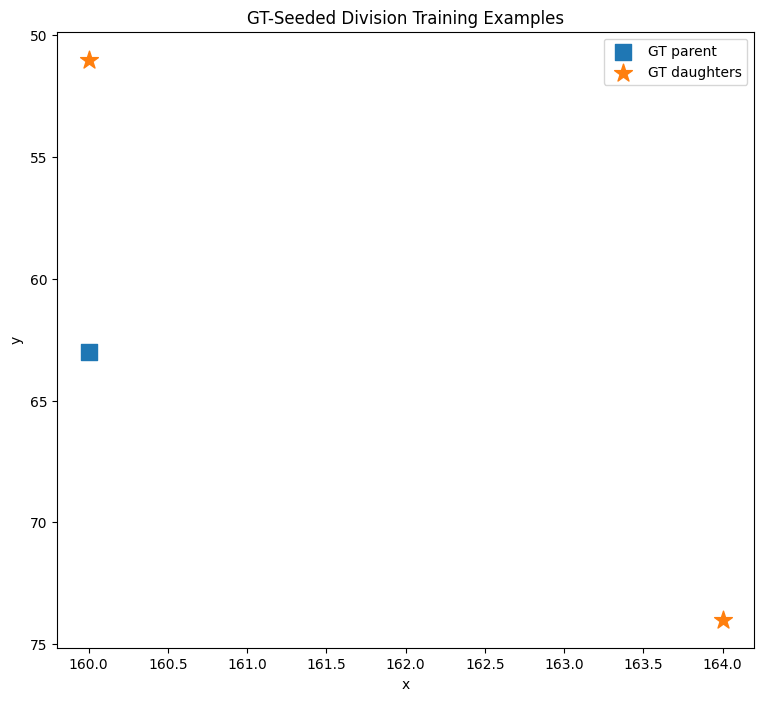

In [15]:
if not gt_divisions_df.empty:
    d=gt_divisions_df.iloc[0]
    plt.figure(figsize=(9,8)); plt.scatter([d.parent_x],[d.parent_y],marker='s',s=140,label='GT parent'); plt.scatter([d.daughter_a_x,d.daughter_b_x],[d.daughter_a_y,d.daughter_b_y],marker='*',s=180,label='GT daughters')
    if not positive_examples_df.empty:
        for r in positive_examples_df.head(3).itertuples(index=False):
            for tid in [r.parent_track_id,r.daughter_track_id_a,r.daughter_track_id_b]:
                g=track_groups[int(tid)]; plt.plot(g.x,g.y,marker='o',alpha=.7)
    plt.gca().invert_yaxis(); plt.xlabel('x'); plt.ylabel('y'); plt.title('GT-Seeded Division Training Examples'); plt.legend(); plt.show()

## Step 14 — Define model features and train a preliminary classifier

In [16]:
NON_FEATURE={'sample_id','division_index','gt_parent','gt_daughter_a','gt_daughter_b','parent_track_id','daughter_track_id_a','daughter_track_id_b','division_label','example_type'}
FEATURE_COLUMNS=[col for col in training_examples_df.columns if col not in NON_FEATURE and pd.api.types.is_numeric_dtype(training_examples_df[col])]
print('Features:',len(FEATURE_COLUMNS)); print(FEATURE_COLUMNS)

def make_model():
    try:
        from lightgbm import LGBMClassifier
        clf=LGBMClassifier(objective='binary',n_estimators=250,learning_rate=.03,num_leaves=15,min_child_samples=3,class_weight='balanced',random_state=CONFIG.random_state,verbosity=-1); name='LightGBM'
    except Exception:
        clf=ExtraTreesClassifier(n_estimators=400,class_weight='balanced',random_state=CONFIG.random_state,n_jobs=-1); name='ExtraTrees'
    return Pipeline([('imputer',SimpleImputer(strategy='median')),('classifier',clf)]),name

can_train=pos>=CONFIG.minimum_positive_examples_to_train and neg>=CONFIG.minimum_negative_examples_to_train
model=None; model_name=None; training_predictions_df=pd.DataFrame(); training_metrics_df=pd.DataFrame(); feature_importance_df=pd.DataFrame()
if can_train:
    model,model_name=make_model(); X=training_examples_df[FEATURE_COLUMNS]; y=training_examples_df.division_label.astype(int); model.fit(X,y); prob=model.predict_proba(X)[:,1]; pred=(prob>=.5).astype(int)
    training_predictions_df=training_examples_df[['division_index','parent_track_id','daughter_track_id_a','daughter_track_id_b','division_label','example_type']].copy(); training_predictions_df['division_probability']=prob; training_predictions_df['predicted_label']=pred
    training_metrics_df=pd.DataFrame([{'model':model_name,'rows':len(y),'positives':int(y.sum()),'average_precision':average_precision_score(y,prob),'roc_auc':roc_auc_score(y,prob) if y.nunique()==2 else np.nan,'precision':precision_score(y,pred,zero_division=0),'recall':recall_score(y,pred,zero_division=0),'f1':f1_score(y,pred,zero_division=0),'note':'Training-set diagnostic only; not independent validation.'}]); display(training_metrics_df)
    clf=model.named_steps['classifier']
    if hasattr(clf,'feature_importances_'): feature_importance_df=pd.DataFrame({'feature':FEATURE_COLUMNS,'importance':clf.feature_importances_}).sort_values('importance',ascending=False).reset_index(drop=True); display(feature_importance_df.head(20))
else:
    print('Not enough examples to train. Positive:',pos,'Negative:',neg)

Features: 0
[]
Not enough examples to train. Positive: 0 Negative: 0


## Step 15 — Validate outputs

In [17]:
validation_df=pd.DataFrame([
{'check':'gt_division_found','passed':len(gt_divisions_df)>0,'details':f'{len(gt_divisions_df)} GT divisions'},
{'check':'parent_candidate_found','passed':bool((gt_track_candidates_df.division_role=='parent').any()) if not gt_track_candidates_df.empty else False,'details':'parent role'},
{'check':'daughter_a_candidate_found','passed':bool((gt_track_candidates_df.division_role=='daughter_a').any()) if not gt_track_candidates_df.empty else False,'details':'daughter A role'},
{'check':'daughter_b_candidate_found','passed':bool((gt_track_candidates_df.division_role=='daughter_b').any()) if not gt_track_candidates_df.empty else False,'details':'daughter B role'},
{'check':'positive_labels_created','passed':pos>0,'details':f'{pos} positives'},
{'check':'negative_labels_created','passed':neg>0,'details':f'{neg} negatives'}])
display(validation_df)
print('Chapter 41 validation passed.' if validation_df.passed.all() else 'Chapter 41 completed with checks needing review.')

,check,passed,details
0,gt_division_found,True,1 GT divisions
1,parent_candidate_found,True,parent role
2,daughter_a_candidate_found,False,daughter A role
3,daughter_b_candidate_found,False,daughter B role
4,positive_labels_created,False,0 positives
5,negative_labels_created,False,0 negatives


Chapter 41 completed with checks needing review.


## Step 16 — Save outputs

Yes, save the Chapter 41 outputs. The most important file is `chapter41_gt_seeded_training_examples.csv`.

In [18]:
# ============================================================
# STEP 16 — SAVE CHAPTER 41 OUTPUTS
# ============================================================

from pathlib import Path
import pandas as pd
import json
import joblib


OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# Helper: safely get a dataframe that may or may not exist
# ------------------------------------------------------------

def safe_dataframe(variable_name):
    value = globals().get(
        variable_name,
        None,
    )

    if value is None:
        print(
            f"WARNING: {variable_name} was not created. "
            "Saving an empty CSV."
        )

        return pd.DataFrame()

    if not isinstance(
        value,
        pd.DataFrame,
    ):
        print(
            f"WARNING: {variable_name} is not a DataFrame. "
            "Saving an empty CSV."
        )

        return pd.DataFrame()

    return value


# ------------------------------------------------------------
# Collect Chapter 41 tables safely
# ------------------------------------------------------------

positive_examples_to_save = safe_dataframe(
    "positive_examples_df"
)

negative_examples_to_save = safe_dataframe(
    "negative_examples_df"
)

training_examples_to_save = safe_dataframe(
    "training_examples_df"
)

gt_track_candidates_to_save = safe_dataframe(
    "gt_track_candidates_df"
)

gt_divisions_to_save = safe_dataframe(
    "gt_divisions_df"
)

division_coverage_to_save = safe_dataframe(
    "division_coverage_df"
)

label_audit_to_save = safe_dataframe(
    "label_audit_df"
)

training_predictions_to_save = safe_dataframe(
    "training_predictions_df"
)

training_metrics_to_save = safe_dataframe(
    "training_metrics_df"
)

feature_importance_to_save = safe_dataframe(
    "feature_importance_df"
)

validation_to_save = safe_dataframe(
    "validation_df"
)

diagnostic_summary_to_save = safe_dataframe(
    "diagnostic_summary_df"
)


# ------------------------------------------------------------
# Output paths
# ------------------------------------------------------------

paths = {
    "positives":
        OUTPUT_DIR
        / "chapter41_gt_seeded_positive_examples.csv",

    "negatives":
        OUTPUT_DIR
        / "chapter41_gt_seeded_negative_examples.csv",

    "training":
        OUTPUT_DIR
        / "chapter41_gt_seeded_training_examples.csv",

    "track_candidates":
        OUTPUT_DIR
        / "chapter41_gt_track_candidates.csv",

    "gt_divisions":
        OUTPUT_DIR
        / "chapter41_gt_divisions.csv",

    "coverage":
        OUTPUT_DIR
        / "chapter41_division_candidate_coverage.csv",

    "label_audit":
        OUTPUT_DIR
        / "chapter41_label_audit.csv",

    "training_predictions":
        OUTPUT_DIR
        / "chapter41_training_predictions.csv",

    "training_metrics":
        OUTPUT_DIR
        / "chapter41_training_metrics.csv",

    "feature_importance":
        OUTPUT_DIR
        / "chapter41_feature_importance.csv",

    "validation":
        OUTPUT_DIR
        / "chapter41_output_validation.csv",

    "diagnostic_summary":
        OUTPUT_DIR
        / "chapter41_gt_role_diagnostic_summary.csv",

    "features":
        OUTPUT_DIR
        / "chapter41_feature_columns.json",

    "model":
        OUTPUT_DIR
        / "chapter41_division_model.joblib",
}


# ------------------------------------------------------------
# Save helper
# ------------------------------------------------------------

def save_csv(df, path):
    df.to_csv(
        path,
        index=False,
    )

    print(
        f"Saved: {path.name} "
        f"({len(df):,} rows)"
    )


# ------------------------------------------------------------
# Save CSV files
# ------------------------------------------------------------

save_csv(
    positive_examples_to_save,
    paths["positives"],
)

save_csv(
    negative_examples_to_save,
    paths["negatives"],
)

save_csv(
    training_examples_to_save,
    paths["training"],
)

save_csv(
    gt_track_candidates_to_save,
    paths["track_candidates"],
)

save_csv(
    gt_divisions_to_save,
    paths["gt_divisions"],
)

save_csv(
    division_coverage_to_save,
    paths["coverage"],
)

save_csv(
    label_audit_to_save,
    paths["label_audit"],
)

save_csv(
    training_predictions_to_save,
    paths["training_predictions"],
)

save_csv(
    training_metrics_to_save,
    paths["training_metrics"],
)

save_csv(
    feature_importance_to_save,
    paths["feature_importance"],
)

save_csv(
    validation_to_save,
    paths["validation"],
)

save_csv(
    diagnostic_summary_to_save,
    paths["diagnostic_summary"],
)


# ------------------------------------------------------------
# Safely determine feature/model information
# ------------------------------------------------------------

feature_columns_to_save = globals().get(
    "FEATURE_COLUMNS",
    [],
)

positive_count_to_save = int(
    globals().get(
        "positive_count",
        len(positive_examples_to_save),
    )
)

negative_count_to_save = int(
    globals().get(
        "negative_count",
        len(negative_examples_to_save),
    )
)

model_to_save = globals().get(
    "model",
    None,
)

model_name_to_save = globals().get(
    "model_name",
    None,
)


# ------------------------------------------------------------
# Save feature configuration
# ------------------------------------------------------------

feature_config = {
    "sample_id": CONFIG.sample_id,

    "feature_columns":
        list(feature_columns_to_save),

    "positive_examples":
        positive_count_to_save,

    "negative_examples":
        negative_count_to_save,

    "model_trained":
        model_to_save is not None,

    "model_name":
        model_name_to_save,

    "data39_dir":
        str(DATA39_DIR),

    "data40_dir":
        str(DATA40_DIR),
}


with paths["features"].open(
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        feature_config,
        file,
        indent=2,
    )


print(
    "Saved:",
    paths["features"].name,
)


# ------------------------------------------------------------
# Save model only if one exists
# ------------------------------------------------------------

if model_to_save is not None:

    joblib.dump(
        model_to_save,
        paths["model"],
    )

    print(
        "Saved:",
        paths["model"].name,
    )

else:

    print(
        "Model file not created "
        "because no trained model exists yet."
    )


print()
print("Step 16 complete.")

Saved: chapter41_gt_seeded_positive_examples.csv (0 rows)
Saved: chapter41_gt_seeded_negative_examples.csv (0 rows)
Saved: chapter41_gt_seeded_training_examples.csv (0 rows)
Saved: chapter41_gt_track_candidates.csv (1 rows)
Saved: chapter41_gt_divisions.csv (1 rows)
Saved: chapter41_division_candidate_coverage.csv (0 rows)
Saved: chapter41_label_audit.csv (6 rows)
Saved: chapter41_training_predictions.csv (0 rows)
Saved: chapter41_training_metrics.csv (0 rows)
Saved: chapter41_feature_importance.csv (0 rows)
Saved: chapter41_output_validation.csv (6 rows)
Saved: chapter41_gt_role_diagnostic_summary.csv (0 rows)
Saved: chapter41_feature_columns.json
Model file not created because no trained model exists yet.

Step 16 complete.


## Step 17 — Create ZIP and verify outputs

In [19]:
zip_path=shutil.make_archive(str(OUTPUT_DIR/'chapter41_outputs'),'zip',root_dir=OUTPUT_DIR,base_dir='.')
created=sorted(OUTPUT_DIR.glob('chapter41_*')); verification_df=pd.DataFrame([{'filename':p.name,'size_bytes':p.stat().st_size,'exists':p.exists()} for p in created]); print('Created ZIP:',zip_path); display(verification_df)

Created ZIP: /kaggle/working/chapter41_outputs.zip


,filename,size_bytes,exists
0,chapter41_division_candidate_coverage.csv,1,True
1,chapter41_feature_columns.json,293,True
2,chapter41_feature_importance.csv,1,True
3,chapter41_gt_divisions.csv,274,True
4,chapter41_gt_role_diagnostic_summary.csv,1,True
5,chapter41_gt_seeded_negative_examples.csv,1,True
6,chapter41_gt_seeded_positive_examples.csv,1,True
7,chapter41_gt_seeded_training_examples.csv,1,True
8,chapter41_gt_track_candidates.csv,342,True
9,chapter41_label_audit.csv,155,True


# Chapter 41 Complete

Success means the audit shows both `positive_examples > 0` and `negative_examples > 0`.

Preserve at minimum:

```text
chapter41_gt_seeded_training_examples.csv
chapter41_gt_track_candidates.csv
chapter41_gt_divisions.csv
chapter41_feature_columns.json
chapter41_outputs.zip
```

Next: **Chapter 42 — Multi-Sample GT-Seeded Division Learning**.